In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as f
import torch.optim as optim
import torchvision
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import numpy as np
import random
import matplotlib.pyplot as plt

In [28]:
torchvision.__version__

'0.26.0+cu128'

In [29]:
device="cuda" if torch.cuda.is_available() else "cpu"

In [30]:
torch.cuda.is_available()

True

In [31]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
random.seed(42)

In [32]:
BATCH_SIZE=128
EPOCHS=45
LEARNING_RATE=3e-4
PATCH_SIZE=4
NUM_CLASSES=10
IMAGE_SIZE=32
CHANNELS=3
EMBED_DIM=256
NUM_HEAD=8
DEPTH=6
MLP_DIM=512
DROP_RATE=0.1


In [33]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])
print("Transforms created successfully!")

Transforms created successfully!


In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
!find "/content/drive/MyDrive" -iname "*cifar*" -o -iname "data_batch_1"

/content/drive/MyDrive/cifar-10-batches-py
/content/drive/MyDrive/cifar-10-batches-py/data_batch_1
/content/drive/MyDrive/cifar-10-python (1).tar.gz
/content/drive/MyDrive/cifar-10-python.tar.gz


In [36]:
!gzip -t "/content/drive/MyDrive/cifar-10-python (1).tar.gz"

In [37]:
!tar -xzf "/content/drive/MyDrive/cifar-10-python (1).tar.gz" -C "/content/drive/MyDrive/"

In [38]:
!ls "/content/drive/MyDrive/cifar-10-batches-py"

batches.meta  data_batch_2  data_batch_4  readme.html
data_batch_1  data_batch_3  data_batch_5  test_batch


In [39]:
from torchvision import datasets
from torch.utils.data import random_split

# Create dataset for training
train_full = datasets.CIFAR10(
    root="/content/drive/MyDrive",
    train=True,
    download=False,
    transform=train_transform
)

# Create another copy for validation
val_full = datasets.CIFAR10(
    root="/content/drive/MyDrive",
    train=True,
    download=False,
    transform=val_transform
)
test_dataset = datasets.CIFAR10(
    root="/content/drive/MyDrive",
    train=False,
    download=False,
    transform=val_transform
)
print("Training images:", len(train_full))
print("Test images:", len(test_dataset))

Training images: 50000
Test images: 10000


In [40]:
# Create the same random split for both
generator = torch.Generator().manual_seed(42)

train_dataset, _ = random_split(
    train_full,
    [45000, 5000],
    generator=generator
)

generator = torch.Generator().manual_seed(42)

_, val_dataset = random_split(
    val_full,
    [45000, 5000],
    generator=generator
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Training samples: 45000
Validation samples: 5000


Image shape: torch.Size([3, 32, 32])
Label: 6


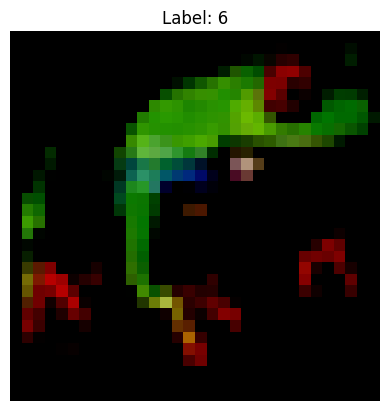

In [41]:
import matplotlib.pyplot as plt

image, label = train_dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

plt.imshow(image.permute(1, 2, 0))
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [42]:
train_loader=DataLoader(
    dataset=train_dataset,
    batch_size=128,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)
test_loader=DataLoader(
     dataset=test_dataset,
     batch_size=128,
     shuffle=False

 )
print("DataLoaders created successfully!")

DataLoaders created successfully!


#lets check out what we have created

In [43]:
print(f"DataLoader:{train_loader,test_loader}")
print(f"Length of train_loader:{len(train_loader)} batches of{BATCH_SIZE}...")
print(f"Length of test_loader:{len(test_loader)} batches of{BATCH_SIZE}...")


DataLoader:(<torch.utils.data.dataloader.DataLoader object at 0x7cf230d05d30>, <torch.utils.data.dataloader.DataLoader object at 0x7cf23ff2f610>)
Length of train_loader:352 batches of128...
Length of test_loader:79 batches of128...


In [44]:
128*391 #the last batch doesnt contain 128..it contains less so the number is rounded

50048

# OUR DATA IS ALSO CONVERETED INTO BATCHES..NOW IMPLEMENTING VIT COMPONENTS

In [45]:
class PatchEmbedding(nn.Module):
    def __init__(self,
                img_size,
                patch_size,
                in_channels,
                embed_dim,
                stride=2):
        super().__init__()

        self.patch_size = patch_size
        self.stride = stride

        self.proj = nn.Conv2d(
            in_channels=in_channels,
            out_channels=embed_dim,
            kernel_size=patch_size,
            stride=stride
        )

        num_patches = ((img_size - patch_size) // stride + 1) ** 2

        self.cls_token = nn.Parameter(
            torch.randn(1, 1, embed_dim)
        )

        self.pos_embed = nn.Parameter(
            torch.randn(1, 1 + num_patches, embed_dim)
        )

    def forward(self, x: torch.Tensor):
        B = x.size(0)

        x = self.proj(x)

        x = x.flatten(2).transpose(1, 2)

        cls_token = self.cls_token.expand(B, -1, -1)

        x = torch.cat((cls_token, x), dim=1)

        x = x + self.pos_embed

        return x

In [46]:
import torch.nn.functional as F

Image
 ↓
Conv2D → patches + embedding
 ↓
Flatten + transpose
 ↓
Add CLS token
 ↓
Add positional embedding
 ↓
Output tokens

In [47]:
class MLP(nn.Module):
    def __init__(self,
                in_features,
                 hidden_features,
                 drop_rate):
        super().__init__()
        self.fc1=nn.Linear(in_features=in_features,
                          out_features=hidden_features)
        self.fc2=nn.Linear(in_features=hidden_features,
                           out_features=in_features)
        self.dropout = nn.Dropout(drop_rate)
    def forward(self,x):
        x=self.dropout(F.gelu(self.fc1(x)))
        x=self.dropout(self.fc2(x))
        return x

#custom layernorm

In [48]:
class LayerNorm(nn.Module):
    def __init__(self, embed_dim, eps=1e-6):
        super().__init__()

        self.gamma = nn.Parameter(torch.ones(embed_dim))
        self.beta = nn.Parameter(torch.zeros(embed_dim))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        variance = x.var(dim=-1, keepdim=True, unbiased=False)

        x = (x - mean) / torch.sqrt(variance + self.eps)

        return self.gamma * x + self.beta

In [49]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, drop_rate):
        super().__init__()

        assert embed_dim % num_heads == 0

        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.q_proj = nn.Linear(embed_dim, embed_dim)
        self.k_proj = nn.Linear(embed_dim, embed_dim)
        self.v_proj = nn.Linear(embed_dim, embed_dim)

        self.out_proj = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(drop_rate)

    def forward(self, x):

        B, N, C = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.reshape(B, N, self.num_heads, self.head_dim)
        k = k.reshape(B, N, self.num_heads, self.head_dim)
        v = v.reshape(B, N, self.num_heads, self.head_dim)

        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        attention_scores = torch.matmul(q, k.transpose(-2, -1))

        attention_scores = attention_scores / (self.head_dim ** 0.5)

        attention_weights = torch.softmax(attention_scores, dim=-1)

        attention_weights = self.dropout(attention_weights)

        x = torch.matmul(attention_weights, v)

        x = x.transpose(1, 2)

        x = x.reshape(B, N, C)

        x = self.out_proj(x)

        return x

In [50]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, drop_rate):
        super().__init__()

        self.norm1 = LayerNorm(embed_dim)

        self.attn = MultiHeadSelfAttention(
            embed_dim,
            num_heads,
            drop_rate
        )

        self.norm2 = LayerNorm(embed_dim)

        self.mlp = MLP(
            embed_dim,
            mlp_dim,
            drop_rate
        )

    def forward(self, x):

        x = x + self.attn(self.norm1(x))

        x = x + self.mlp(self.norm2(x))

        return x

#combine all of these above components of a transformer
t doesn't rewrite all the attention, MLP, patch embedding code again. Instead, it calls the classes/functions we already created and connects them together.

In [51]:
class VisionTransformer(nn.Module):
    def __init__(self,img_size,patch_size,in_channels,num_classes,embed_dim,depth,num_heads,mlp_dim,drop_rate):
        super().__init__()
        self.patch_embed=PatchEmbedding(img_size,patch_size,in_channels,embed_dim)
        self.encoder=nn.Sequential(*[
            TransformerEncoderLayer(embed_dim,num_heads,mlp_dim,drop_rate)
            for _ in range(depth)
        ]
        )
        self.norm= LayerNorm(embed_dim)
        self.head=nn.Linear(embed_dim,num_classes)
    def forward(self,x):
        x=self.patch_embed(x)
        x=self.encoder(x)
        x=self.norm(x)
        cls_token=x[:,0]
        return self.head(cls_token)


In [52]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


we create a instance for our vision transformer classes to use that and above classes

In [53]:
model=VisionTransformer(
     IMAGE_SIZE,PATCH_SIZE,CHANNELS,NUM_CLASSES
    ,EMBED_DIM,DEPTH,NUM_HEAD,MLP_DIM,DROP_RATE).to(device)

print("New model created on:", next(model.parameters()).device)

New model created on: cuda:0


In [54]:
print("Number of patches:", model.patch_embed.pos_embed.shape[1] - 1)
print("Total tokens:", model.patch_embed.pos_embed.shape[1])

Number of patches: 225
Total tokens: 226


In [ ]:
x = torch.randn(2, 3, 32, 32).to(device)

output = model(x)

print(output.shape)

torch.Size([2, 10])


above cell is to just check whether vit forward pass is working correctly or not.


#DEFINING LOSS FUNCTION AND OPTIMIZER

NOW WE WILL write LOSS FUNCTION
how the model measures its prediction error.

In [55]:
criterion=nn.CrossEntropyLoss() #mesure how wrong our model is
optimizer=torch.optim.Adam(params=model.parameters(),
                          lr=LEARNING_RATE)# update our model parameters(weights) to try and reduce the loss

In [56]:
def train(model,loader,optimizer,criterion):
    #set the mode of the model into training mode
    model.train()
    total_loss,correct=0,0 #for caluclating loss and corectness
    for x,y in loader:  #x for loop in images and y for loop in labels (batch wise)
        x,y=x.to(device),y.to(device)
        optimizer.zero_grad()
    #1.forward pass (model outputs raw logistics)
        out=model(x)
    #2.loss caluclation
        loss=criterion(out,y)
    #3.perform back propagation
        loss.backward()
    #4.perform gradient descent
        optimizer.step()#this function also perform graient descent
        total_loss+=loss.item()*x.size(0)
        correct+=(out.argmax(1)==y).sum().item()
    #you have to scale the loss (NOrmalization step to make the loss general across all batches)
    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset)
    return avg_loss,accuracy

#VALIDATION FUNCTION For verifying not to teach

In [57]:
def validate(model, loader, criterion):

    # Set model to evaluation mode
    model.eval()

    total_loss, correct = 0, 0

    # No gradient calculation during validation
    with torch.no_grad():

        for x, y in loader:

            x, y = x.to(device), y.to(device)

            # Forward pass
            out = model(x)

            # Calculate loss
            loss = criterion(out, y)

            total_loss += loss.item() * x.size(0)

            # Count correct predictions
            correct += (out.argmax(1) == y).sum().item()

    # Average validation loss
    avg_loss = total_loss / len(loader.dataset)

    # Validation accuracy
    accuracy = correct / len(loader.dataset)

    return avg_loss, accuracy

In [58]:
import torch.nn.functional as F

In [59]:
import copy
best_val_acc = 0.0
best_model_state=None

for epoch in range(EPOCHS):

    train_loss, train_acc = train(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )



    # Save the best model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )
    torch.save({
    'epoch': epoch,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_acc': val_acc
}, "/content/drive/MyDrive/vit_checkpoint.pth")

print("Best Validation Accuracy:", best_val_acc)

Epoch [1/45] Train Loss: 1.8842 Train Acc: 0.3044 Val Loss: 1.6049 Val Acc: 0.4234
Epoch [2/45] Train Loss: 1.5562 Train Acc: 0.4305 Val Loss: 1.4333 Val Acc: 0.4764
Epoch [3/45] Train Loss: 1.4258 Train Acc: 0.4824 Val Loss: 1.2997 Val Acc: 0.5334
Epoch [4/45] Train Loss: 1.3375 Train Acc: 0.5161 Val Loss: 1.2080 Val Acc: 0.5624
Epoch [5/45] Train Loss: 1.2579 Train Acc: 0.5463 Val Loss: 1.2123 Val Acc: 0.5624
Epoch [6/45] Train Loss: 1.1949 Train Acc: 0.5721 Val Loss: 1.1498 Val Acc: 0.5820
Epoch [7/45] Train Loss: 1.1361 Train Acc: 0.5911 Val Loss: 1.0558 Val Acc: 0.6200
Epoch [8/45] Train Loss: 1.0851 Train Acc: 0.6124 Val Loss: 1.0366 Val Acc: 0.6324
Epoch [9/45] Train Loss: 1.0338 Train Acc: 0.6323 Val Loss: 1.0243 Val Acc: 0.6356
Epoch [10/45] Train Loss: 0.9950 Train Acc: 0.6458 Val Loss: 0.9621 Val Acc: 0.6520
Epoch [11/45] Train Loss: 0.9583 Train Acc: 0.6541 Val Loss: 0.9463 Val Acc: 0.6610
Epoch [12/45] Train Loss: 0.9167 Train Acc: 0.6722 Val Loss: 0.8927 Val Acc: 0.6790
E

In [60]:
model = model.to(device)
print(next(model.parameters()).device)

cuda:0


In [61]:
model.load_state_dict(best_model_state)

print("Best model loaded.")

Best model loaded.


In [62]:
test_loss, test_acc = validate(
    model,
    test_loader,
    criterion
)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Loss: 0.8055
Final Test Accuracy: 0.7725
